# play around with pvae model

project = ```P-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

Goal: `MetabolicCost`

In [1]:
# HIDE CODE


project_name = 'PoissonVAE'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Load dir

In [3]:
load_dir = 'Dropbox/chkpts/PoissonVAE'
load_dir = add_home(load_dir)

len(os.listdir(load_dir))

179

In [4]:
fit_name = next(
    f for f in os.listdir(load_dir) if all(
        item in f for item in
        ['MetabolicCost', 'k-512', 'b-1', 'poisson'] # 'gaussian+relu']
))
print(fit_name)

poisson-<lin|lin>-vH16-b-1.5_k-512-MetabolicCost_mach-0_(2025_10_12,17:02)

In [5]:
tr, meta = load_model_lite(
    pjoin(load_dir, fit_name),
    device=device,
    shuffle=False,
    verbose=False,
    strict=True,
)

In [6]:
tr

In [7]:
data, loss, etc = tr.validate(full_data=True)

In [10]:
list(etc)

['log_dr', 'r*dr']

In [11]:
etc['r*dr'].shape

(25811, 512)

In [12]:
etc['r*dr'].mean()

0.39351875

In [13]:
u0 = tonp(tr.model.log_rate.squeeze())
r0 = np.exp(u0)
r0.mean()

0.4264283

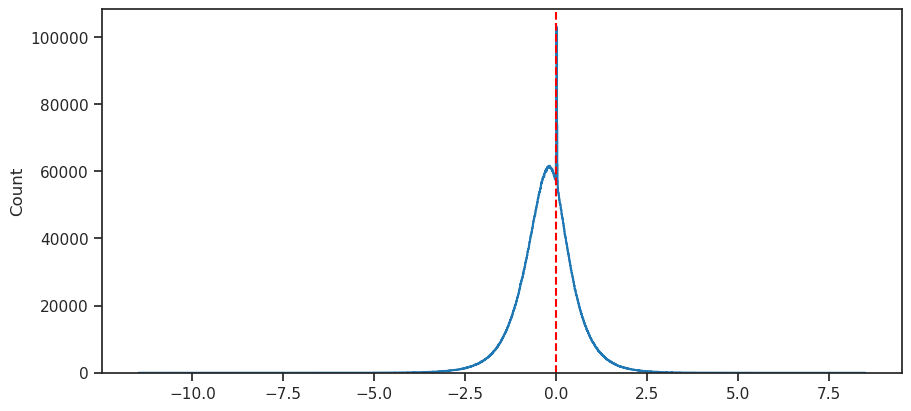

In [14]:
fig, ax = create_figure(1, 1, (9, 4))
histplot(etc['log_dr'].ravel())
ax.axvline(0, color='r', ls='--')
plt.show()

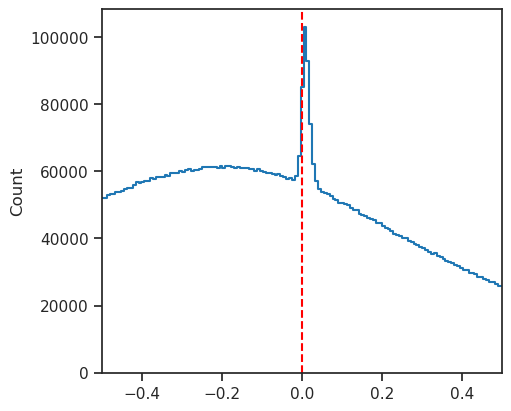

In [15]:
fig, ax = create_figure(1, 1, (5, 4))
histplot(etc['log_dr'].ravel())
ax.axvline(0, color='r', ls='--')
ax.set_xlim(-0.5, 0.5)
plt.show()

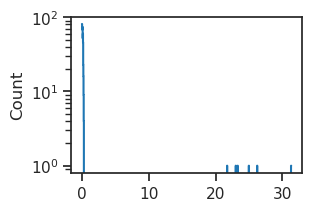

In [16]:
fig, ax = create_figure()
histplot(etc['r*dr'].mean(0))
ax.set_yscale('log')
plt.show()

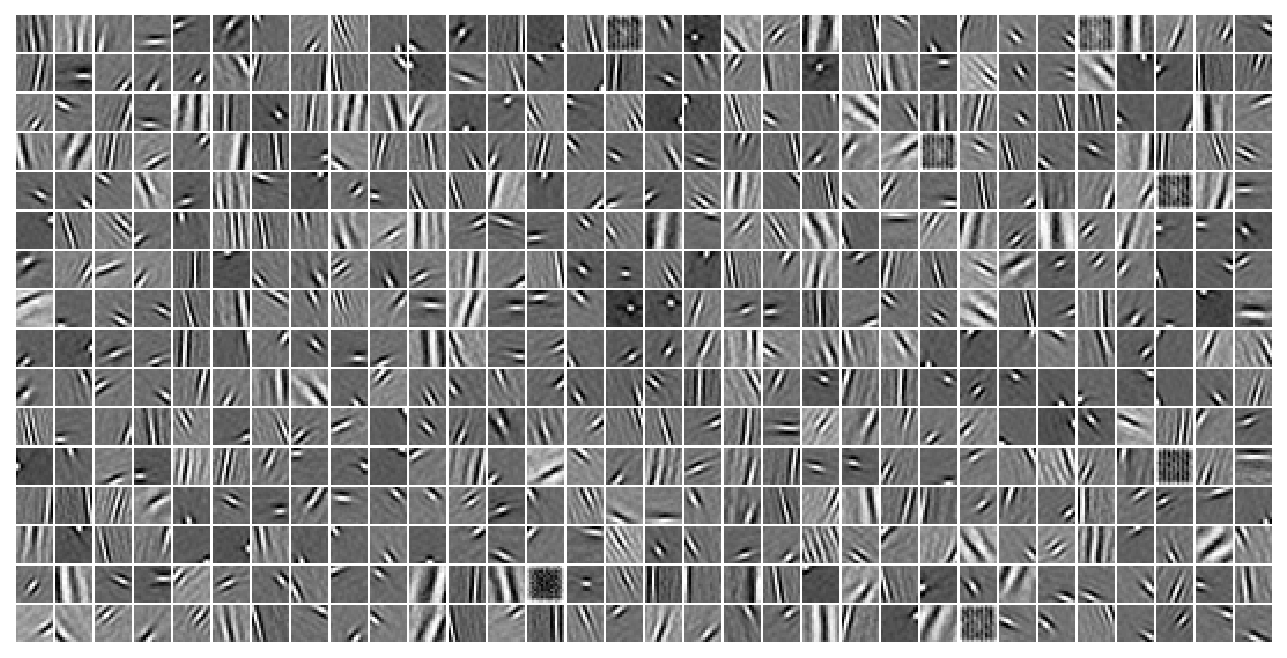

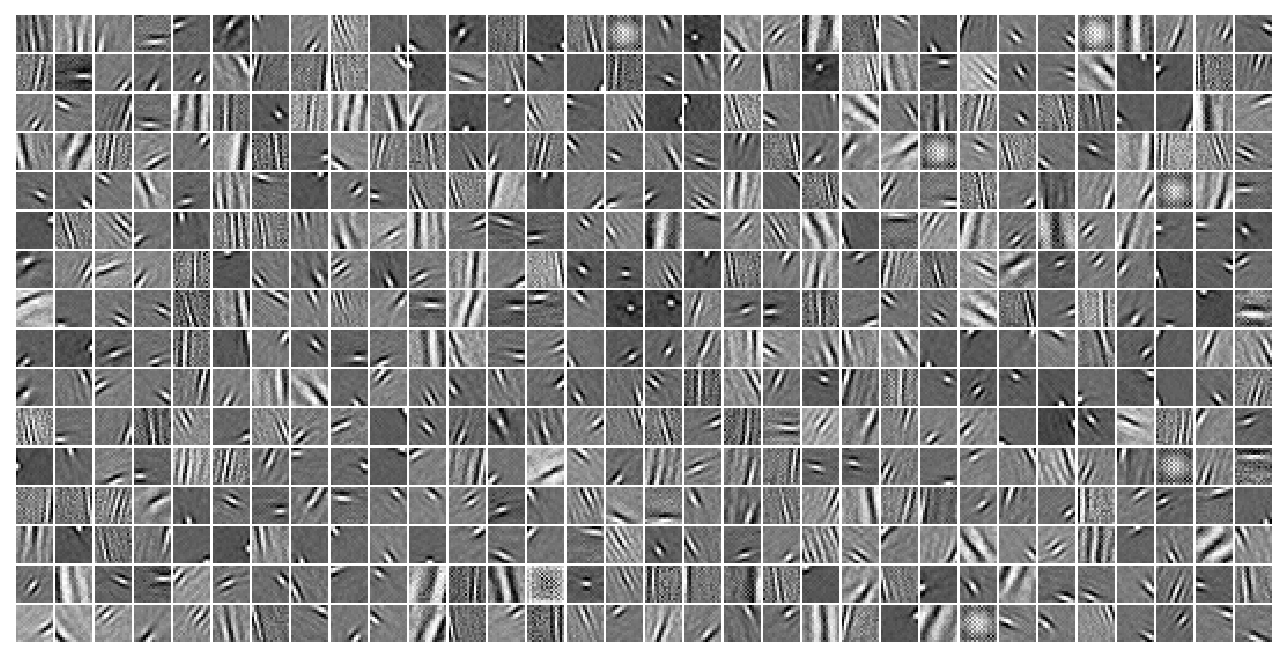

In [17]:
tr.model.show('dec');
tr.model.show('enc');